# Calculate and gap-fill `VPD` (2004-2025)

**notebook version**: `1` (20 Jul 2026)

## ℹ️ About this notebook

Computes vapour pressure deficit `VPD` from the two products that precede it, gap-fills the result
with XGBoost and stores it to the external data folder.

Unlike `31`-`36` this notebook **does not download anything**. Both of its inputs are files written
by earlier notebooks in this stage, so `32` and `34` have to be run before it:

- `TA_T1_47_1_gfXG` — gap-filled air temperature from notebook `32`, **complete** over the record
- `RH_T1_47_1` — corrected relative humidity from notebook `34`, **with gaps**, not gap-filled

`VPD` follows from `TA` and `RH` alone, so it can only be computed where `RH` has a value. Notebook
`34` says so explicitly in its closing note. Everything `RH` is missing is therefore a `VPD` gap,
and filling those gaps is the second half of this notebook.

**Output columns:**

- `VPD_T1_47_1_gfXG` — the gap-filled series (kPa, complete)
- `FLAG_VPD_T1_47_1_ISFILLED` — how each record was obtained; `0` = computed from measured `TA`
  **and** measured `RH`, `>0` = anything else (see `FLAG_LEGEND` below)

The flag keeps the `31`-`33` rule that `0` means "measured and nothing else", but it carries two
extra codes that the earlier notebooks do not need. `VPD` is a **derived** variable: a record can
be computed rather than modelled and still not rest on two measurements, because `TA` may have been
gap-filled by notebook `32` or `RH` reconstructed from NABEL by notebook `34`. Codes `5` and `6`
mark those cases, so no record inherits an unearned `0`. This is the same trap notebook `33`
documents, one step further downstream: a value that *looks* measured because the thing that made
it was not checked.

::: {.callout-note title="Relation to the retired notebook 13"}
`13_CalcVPD_2004-2024` was the earlier approach. It read the combined `METEO6` product, called the
same `calc_vpd_from_ta_rh`, and filled the result with `XGBoostTS` using `SW_IN` and `TA` as
features. It is superseded here: this notebook reads the per-variable products of `32` and `34`
instead of a merged file, adds `SW_IN_POT` as a driver, and tracks where each `VPD` value actually
comes from. `13` is retired and is not run.
:::

***

# Info about data sources

Both inputs are parquet files in the external data folder, written by earlier notebooks in this
stage. Nothing is read from the database here.

| file | column used | from | completeness |
|---|---|---|---|
| `02_METEO_TA_GAPFILLED_2004-2025` | `TA_T1_47_1_gfXG` | notebook `32` | complete |
| `02_METEO_TA_GAPFILLED_2004-2025` | `FLAG_TA_T1_47_1_ISFILLED` | notebook `32` | complete |
| `04_METEO_RH_CORRECTED_2004-2025` | `RH_T1_47_1` | notebook `34` | **gaps** |
| `04_METEO_RH_CORRECTED_2004-2025` | `FLAG_RH_T1_47_1_MISSING` | notebook `34` | complete |
| `01_METEO_SW_IN_GAPFILLED_2004-2025` | `SW_IN_T1_47_1_gfXG` | notebook `31` | complete |

`SW_IN` is used **only as a gap-filling driver**; it plays no part in the `VPD` calculation itself.

The two input flags are read as well, not just the values. They are what makes the provenance of
each computed `VPD` knowable — without them every computed record would look equally measured.

## ⏱️ Timestamp convention

Every input file already carries a sanitised, continuous 30MIN `TIMESTAMP_MID` index in local time
(UTC + `TIMEZONE_OFFSET_TO_UTC_HOURS`), produced by the `TimestampSanitizer` call in the notebook
that wrote it. This notebook does not shift or resample anything; it asserts that the indices agree
and works on them as they are.

The offset is still needed here, because `SW_IN_POT` is computed from the site coordinates and has
to land on the same local-time axis as the data.

***

# ⚙️ Settings

## Data settings

In [1]:
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # Timezone, e.g. "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'  # Expected resolution of the input files; asserted below
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

TARGET = "VPD_T1_47_1"  # variable computed and exported here

# Inputs: products of the earlier notebooks of this stage, in the external data folder.
# There is no database download in this notebook.
TA_FILE = "32_METEO_TA_GAPFILLED_2004-2025"
TA_COL = "TA_T1_47_1_gfXG"
TA_FLAGCOL = "FLAG_TA_T1_47_1_ISFILLED"

RH_FILE = "34_METEO_RH_CORRECTED_2004-2025"
RH_COL = "RH_T1_47_1"
RH_FLAGCOL = "FLAG_RH_T1_47_1_MISSING"
RH_FLAG_RECONSTRUCTED = 3  # code 3 in notebook 04 = reconstructed from the NABEL sensor at 49 m

SWIN_FILE = "31_METEO_SW_IN_GAPFILLED_2004-2025"
SWIN_COL = "SW_IN_T1_47_1_gfXG"

# Output: data files live in the external (untracked) data folder, with the same
# numeric prefix as this notebook.
OUTNAME = "37_METEO_VPD_GAPFILLED_2004-2025"
OUTPATH = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"

# Plausible VPD at this site, in kPa. VPD is zero at saturation and cannot be negative; the upper
# bound is generous (the record maximum is around 4 kPa) and only has to catch a unit or formula
# error, which would be off by a factor of 10 (hPa) or more.
VPD_PLAUSIBLE_KPA = (0.0, 10.0)

## Imports

In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme('notebook')

import diive as dv

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

# Start time is kept so the last cell can report the total runtime of the notebook.
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-07-20 14:52:05
diive version: v0.91.0


In [3]:
# Result flags used in this notebook.
#
# 0/1/2 are the standard diive gap-filling flags (see GapFillingResult) and 4 is the short-gap
# interpolation, exactly as in notebooks 01 and 02, so all three products speak the same language
# for the records this notebook models.
#
# 5 and 6 are specific to VPD and exist because VPD is DERIVED. A record can be computed rather
# than modelled and still not rest on two measurements: notebook 02 may have gap-filled the TA that
# went into it, or notebook 04 may have reconstructed the RH from the NABEL sensor. Those records
# are not "gap-filled VPD" - no VPD model touched them - but they are not measurements either, so
# they must not be labelled 0.
#
# The 01-03 convention still holds unchanged: 0 means measured and nothing else, > 0 means anything
# else, so a downstream `flag == 0` filter stays conservative.
FLAG_LEGEND = {
    0: '0 = computed from measured TA and measured RH',
    1: '1 = gap-filled by the XGBoost model',
    2: '2 = gap-filled by the timestamp-only fallback model (a driver was missing)',
    4: '4 = gap-filled by linear interpolation (short gap)',
    5: '5 = computed from measured RH and gap-filled TA',
    6: '6 = computed from RH reconstructed from NABEL (TA measured or gap-filled)',
}

# Records whose value follows from TA and RH by the formula, with no VPD model involved.
COMPUTED_FLAGS = (0, 5, 6)
# Records whose value was produced by the gap-filling in this notebook.
MODELLED_FLAGS = (1, 2, 4)

## Helper functions

Three helpers, each with the job of failing loudly rather than quietly doing nothing:

- `load_product()` reads one of the input files and **refuses** anything whose index is not a
  continuous, duplicate-free 30MIN series or that is missing the columns asked for. Every later
  step aligns three files on a shared index, and a silently mis-shaped input would produce a
  `VPD` full of `NaN` that still had the right length.
- `short_gap_mask()` selects whole gap runs no longer than a limit. Same helper as notebook `32`.
- `check_vpd_range()` is the physical guard on the result, used twice: on the computed `VPD` and
  again on the exported series.

In [4]:
def load_product(filename: str, columns: list[str]) -> pd.DataFrame:
    """Load one stage-10 product and verify it is usable as an input here.

    Raises rather than returning a frame that would quietly poison the merge: missing columns, a
    non-30MIN index, duplicate timestamps or an index with holes all stop the notebook.
    """
    filepath = Path(OUTPATH) / f"{filename}.parquet"
    if not filepath.is_file():
        raise FileNotFoundError(
            f"{filepath} does not exist. Run the notebook that produces it before this one.")

    df = dv.load_parquet(filepath=str(filepath))

    missing = [c for c in columns if c not in df.columns]
    if missing:
        raise ValueError(f"{filename}: expected column(s) {missing}, found {list(df.columns)}.")
    if df.index.duplicated().any():
        raise ValueError(f"{filename}: {int(df.index.duplicated().sum())} duplicate timestamps.")

    steps = df.index.to_series().diff().dropna().unique()
    expected = pd.Timedelta(REQUIRED_TIME_RESOLUTION)
    if len(steps) != 1 or steps[0] != expected:
        raise ValueError(
            f"{filename}: index is not a continuous {REQUIRED_TIME_RESOLUTION} series "
            f"(found step(s) {list(steps)}).")

    out = df[columns].copy()
    print(f"  {filename:<38} {out.index[0]} -> {out.index[-1]}  ({len(out):,} records)")
    return out


def short_gap_mask(series: pd.Series, limit: int) -> pd.Series:
    """True where `series` is missing AND its whole gap is at most `limit` records long.

    Whole runs are selected explicitly. Using pandas' `interpolate(limit=)` instead would fill
    the first `limit` records of a long gap as well, which is not wanted: those values would sit
    on a straight line spanning the entire gap.
    """
    missing = series.isna()
    run_length = missing.groupby((~missing).cumsum()).transform('sum')
    return missing & (run_length <= limit)


def check_vpd_range(series: pd.Series, label: str) -> None:
    """Assert that every value present is plausible VPD in kPa.

    A formula slip or a unit mix-up (hPa instead of kPa) shows up here as a factor of 10, and a
    negative value means either an RH above 100% survived upstream or a model prediction was not
    clipped.
    """
    lo, hi = VPD_PLAUSIBLE_KPA
    values = series.dropna()
    if values.empty:
        raise ValueError(f"{label}: no values at all.")
    if values.min() < lo or values.max() > hi:
        raise ValueError(
            f"{label}: range {values.min():.3f}..{values.max():.3f} kPa is outside the plausible "
            f"{lo}..{hi} kPa. VPD is ~0-4 kPa here; a factor of 10 means hPa.")
    print(f"  {label:<34} n={len(values):>7,}  "
          f"median {float(values.median()):.3f}  range {values.min():.3f}..{values.max():.3f} kPa")

### The guards actually guard

Both `load_product()` and `check_vpd_range()` can only earn their place if their failure path
works, so it is exercised here. Each of these must raise. If this cell prints anything other than
caught exceptions, do not trust the rest of the notebook.

In [5]:
# 1. A column that does not exist must be refused, not silently dropped.
try:
    load_product(TA_FILE, [TA_COL, 'NO_SUCH_COLUMN'])
    raise AssertionError("load_product accepted a missing column - the guard is broken.")
except ValueError as exc:
    print(f"OK, raised as intended:\n  {exc}\n")

# 2. VPD in hPa (i.e. 10x too large) must be refused.
try:
    check_vpd_range(pd.Series([5.0, 12.0, 30.0]), 'VPD in hPa by mistake')
    raise AssertionError("check_vpd_range accepted hPa-magnitude values - the guard is broken.")
except ValueError as exc:
    print(f"OK, raised as intended:\n  {exc}\n")

# 3. A negative VPD must be refused.
try:
    check_vpd_range(pd.Series([0.4, -0.01, 1.2]), 'VPD with a negative value')
    raise AssertionError("check_vpd_range accepted a negative VPD - the guard is broken.")
except ValueError as exc:
    print(f"OK, raised as intended:\n  {exc}")

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\02_METEO
_TA_GAPFILLED_2004-2025.parquet (1.142 seconds).

OK, raised as intended:
  02_METEO_TA_GAPFILLED_2004-2025: expected column(s) ['NO_SUCH_COLUMN'], found ['TA_T1_47_1_gfXG', 'FLAG_TA_T1_47_1_ISFILLED'].

OK, raised as intended:
  VPD in hPa by mistake: range 5.000..30.000 kPa is outside the plausible 0.0..10.0 kPa. VPD is ~0-4 kPa here; a factor of 10 means hPa.

OK, raised as intended:
  VPD with a negative value: range -0.010..1.200 kPa is outside the plausible 0.0..10.0 kPa. VPD is ~0-4 kPa here; a factor of 10 means hPa.


***

# ⬇️ Load inputs

No database connection is needed. The three files below are read from the external data folder,
each of them the output of an earlier notebook in this stage.

In [6]:
print("Loading stage-10 products:")
ta_in = load_product(TA_FILE, [TA_COL, TA_FLAGCOL])
rh_in = load_product(RH_FILE, [RH_COL, RH_FLAGCOL])
swin_in = load_product(SWIN_FILE, [SWIN_COL])

Loading stage-10 products:


> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\02_METEO
_TA_GAPFILLED_2004-2025.parquet (0.015 seconds).

  02_METEO_TA_GAPFILLED_2004-2025        2004-01-01 00:15:00 -> 2025-12-31 23:45:00  (385,728 records)


> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\04_METEO
_RH_CORRECTED_2004-2025.parquet (0.144 seconds).

  04_METEO_RH_CORRECTED_2004-2025        2004-01-01 00:15:00 -> 2025-12-31 23:45:00  (385,728 records)


> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\01_METEO
_SW_IN_GAPFILLED_2004-2025.parquet (0.132 seconds).

  01_METEO_SW_IN_GAPFILLED_2004-2025     2004-01-01 00:15:00 -> 2025-12-31 23:45:00  (385,728 records)


## Align on one index

The three files are expected to cover the same period, but that is asserted rather than assumed.
The working index is their **intersection**, so a future input with a shorter record shortens the
product instead of filling the difference with `NaN` that would later be modelled as if it were a
genuine gap.

In [7]:
common_index = ta_in.index.intersection(rh_in.index).intersection(swin_in.index)
common_index.name = ta_in.index.name

for _label, _df in [('TA', ta_in), ('RH', rh_in), ('SW_IN', swin_in)]:
    _dropped = len(_df) - len(common_index)
    print(f"{_label:<6} {len(_df):>7,} records, {_dropped:>5,} outside the common index")

assert len(common_index) > 0, "the three inputs do not overlap at all"

df = pd.DataFrame(index=common_index)
df[TA_COL] = ta_in[TA_COL]
df[TA_FLAGCOL] = ta_in[TA_FLAGCOL]
df[RH_COL] = rh_in[RH_COL]
df[RH_FLAGCOL] = rh_in[RH_FLAGCOL]
df[SWIN_COL] = swin_in[SWIN_COL]

print(f"\nWorking index: {df.index[0]} -> {df.index[-1]}  ({len(df):,} records)")

# TA and SW_IN arrive gap-filled and must be complete; RH is expected to have gaps.
assert df[TA_COL].notna().all(), f"{TA_COL} has gaps but notebook 02 exports a complete series"
assert df[SWIN_COL].notna().all(), f"{SWIN_COL} has gaps but notebook 01 exports a complete series"
assert df[TA_FLAGCOL].notna().all(), f"{TA_FLAGCOL} has missing flags"
assert df[RH_FLAGCOL].notna().all(), f"{RH_FLAGCOL} has missing flags"

print(f"{RH_COL}: {df[RH_COL].notna().sum():,} of {len(df):,} records "
      f"({100 * df[RH_COL].notna().mean():.2f}%) - the rest become VPD gaps")
df

TA     385,728 records,     0 outside the common index
RH     385,728 records,     0 outside the common index
SW_IN  385,728 records,     0 outside the common index

Working index: 2004-01-01 00:15:00 -> 2025-12-31 23:45:00  (385,728 records)
RH_T1_47_1: 384,808 of 385,728 records (99.76%) - the rest become VPD gaps


,TA_T1_47_1_gfXG,FLAG_TA_T1_47_1_ISFILLED,RH_T1_47_1,FLAG_RH_T1_47_1_MISSING,SW_IN_T1_47_1_gfXG
TIMESTAMP_MIDDLE,,,,,
2004-01-01 00:15:00,-3.312291,1,97.718962,3,0.0
2004-01-01 00:45:00,-3.334407,1,96.918962,3,0.0
2004-01-01 01:15:00,-3.218955,1,93.552296,3,0.0
2004-01-01 01:45:00,-3.328506,1,92.652296,3,0.0
2004-01-01 02:15:00,-3.315091,1,93.985629,3,0.0
...,...,...,...,...,...
2025-12-31 21:45:00,-3.081644,0,42.332976,0,0.0
2025-12-31 22:15:00,-3.084372,0,39.230344,0,0.0
2025-12-31 22:45:00,-3.423939,0,55.771803,0,0.0


### Provenance carried by the inputs

Where the non-`0` codes sit decides which `VPD` records can be labelled `0` further down. Notebook
`32`'s flag names the model that produced a `TA`; notebook `34`'s flag says whether an `RH` was
measured at 47 m, reconstructed from NABEL, or is simply absent.

In [8]:
_ta_counts = df[TA_FLAGCOL].value_counts().sort_index()
_rh_counts = df[RH_FLAGCOL].value_counts().sort_index()

print(f"{TA_FLAGCOL} (0 = measured, > 0 = filled by notebook 02):")
display(pd.DataFrame({'count': _ta_counts, '%': (100 * _ta_counts / len(df)).round(2)}))

print(f"{RH_FLAGCOL} (0 = measured, 1/2 = missing, 3 = reconstructed from NABEL):")
display(pd.DataFrame({'count': _rh_counts, '%': (100 * _rh_counts / len(df)).round(2)}))

FLAG_TA_T1_47_1_ISFILLED (0 = measured, > 0 = filled by notebook 02):


,count,%
FLAG_TA_T1_47_1_ISFILLED,,
0,369065,95.68
1,16485,4.27
4,178,0.05


FLAG_RH_T1_47_1_MISSING (0 = measured, 1/2 = missing, 3 = reconstructed from NABEL):


,count,%
FLAG_RH_T1_47_1_MISSING,,
0,369079,95.68
1,920,0.24
3,15729,4.08


***

# 🧮 Calculate `VPD`

`VPD` is the difference between the saturation vapour pressure at the given air temperature and the
actual vapour pressure, so it follows from `TA` and `RH` alone:

$$
\mathrm{VPD} = e_{sat}(T_a)\left(1 - \frac{\mathrm{RH}}{100}\right)
$$

`diive`'s `calc_vpd_from_ta_rh()` implements this with the Magnus coefficients used by **ReddyProc**
(Kolle Logger Tools Software 2012, valid for water between 0 and 100 °C) and returns **kPa**:

```
VPD [hPa] = 6.1078 * (1 - RH/100) * exp(17.08085 * TA / (234.175 + TA))
```

Two consequences of the formula are worth stating before the numbers appear:

- **`VPD` is zero at saturation and never negative.** `RH` arrives from notebook `34` already
  capped at 100%, so the computed series cannot be negative. The model predictions later on can be,
  and are clipped where they are.
- **`VPD` is missing exactly where `RH` is missing**, because `TA` is complete. So the gap pattern
  of the computed series is `RH`'s gap pattern, and that is checked rather than assumed.

In [9]:
df[TARGET] = dv.variables.calc_vpd_from_ta_rh(df=df, rh_col=RH_COL, ta_col=TA_COL)

print("Computed VPD:")
check_vpd_range(df[TARGET], TARGET)

# The gap pattern must be RH's gap pattern and nothing else. If these ever disagree, either TA
# arrived incomplete or the formula produced NaN from valid inputs; both are bugs, not data.
_vpd_missing = df[TARGET].isna()
_rh_missing = df[RH_COL].isna()
print(f"\nVPD missing: {int(_vpd_missing.sum()):,}   RH missing: {int(_rh_missing.sum()):,}")
assert _vpd_missing.equals(_rh_missing), \
    "VPD is missing where RH is not (or vice versa) - TA incomplete, or a formula problem"
print("VPD gaps are exactly RH's gaps, as expected.")

Computed VPD:
  VPD_T1_47_1                        n=384,808  median 0.171  range 0.000..4.036 kPa

VPD missing: 920   RH missing: 920
VPD gaps are exactly RH's gaps, as expected.


## Provenance of the computed `VPD`

Every record that has a value at this point was computed by the formula, so **none of it is
modelled**. That is not the same as measured, and this is where the distinction is written down
rather than left to be inferred later.

A computed record gets:

- `0` if both inputs were measurements (`TA` flag `0` **and** `RH` flag `0`)
- `5` if `RH` was measured but `TA` came from notebook `32`'s gap-filling
- `6` if `RH` was reconstructed from the NABEL sensor at 49 m, whatever `TA` was

`6` outranks `5` because it is the larger error: notebook `34` puts about **3 % RH** of uncertainty
on a reconstructed value, and `RH` enters the formula linearly, so at typical summer conditions
that is a few tenths of a kPa — considerably more than a gap-filled `TA` contributes.

The mask is built **now**, before any gap-filling writes values into the missing records. Doing it
afterwards is precisely the mistake notebook `33` records: a later step that puts a value into an
empty record makes a modelled value indistinguishable from a measured one.

In [10]:
# Built while the gaps are still gaps. `computed` is the set of records the formula produced.
computed = df[TARGET].notna()

provenance = pd.Series(np.nan, index=df.index, name=f"FLAG_{TARGET}_ISFILLED")
provenance[computed & (df[TA_FLAGCOL] == 0) & (df[RH_FLAGCOL] == 0)] = 0
provenance[computed & (df[TA_FLAGCOL] > 0) & (df[RH_FLAGCOL] == 0)] = 5
provenance[computed & (df[RH_FLAGCOL] == RH_FLAG_RECONSTRUCTED)] = 6   # outranks 5, see above

# Every computed record must have been classified, and nothing else may have been.
assert provenance.notna().equals(computed), \
    "a computed record was left unclassified, or a gap was classified"

_counts = provenance.value_counts().sort_index()
display(pd.DataFrame({'count': _counts.astype(int),
                      '% of record': (100 * _counts / len(df)).round(2)})
        .rename(index=FLAG_LEGEND))
print(f"Computed: {int(computed.sum()):,} ({100 * computed.mean():.2f}%)  |  "
      f"To be gap-filled: {int((~computed).sum()):,} ({100 * (~computed).mean():.2f}%)")

,count,% of record
FLAG_VPD_T1_47_1_ISFILLED,,
0 = computed from measured TA and measured RH,369056,95.68
5 = computed from measured RH and gap-filled TA,23,0.01
6 = computed from RH reconstructed from NABEL (TA measured or gap-filled),15729,4.08


Computed: 384,808 (99.76%)  |  To be gap-filled: 920 (0.24%)


## Plots: the computed series and its inputs

The two heatmaps of the inputs and the one of `VPD` should share the same white areas, since `TA`
is complete and `RH` is not. `VPD` has a strong diurnal and seasonal structure — high on summer
afternoons, near zero at night and in winter — and a heatmap that does not show it would mean the
timestamps or the formula are wrong.

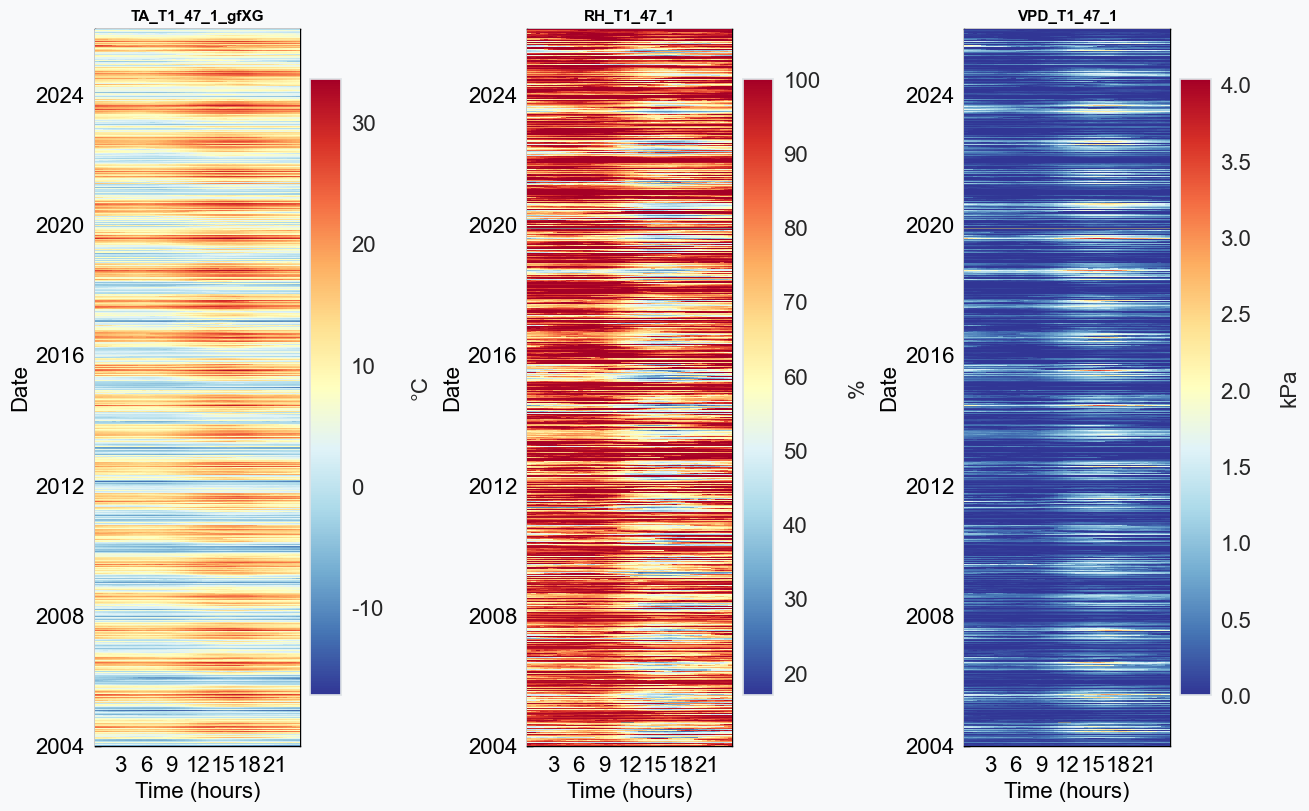

In [11]:
fig, axs = plt.subplots(ncols=3, figsize=(13, 8), dpi=100, layout='constrained')
for _ax, _col, _z, _dig in [(axs[0], TA_COL, '°C', 0),
                            (axs[1], RH_COL, '%', 0),
                            (axs[2], TARGET, 'kPa', 1)]:
    dv.plotting.HeatmapDateTime(series=df[_col]).plot(
        ax=_ax, cb_digits_after_comma=_dig, zlabel=_z,
        format_style=dv.plotting.FormatStyle(title=_col, title_fontsize=11))

Text(0.5, 1.0, 'Median VPD by month (peaks in summer)')

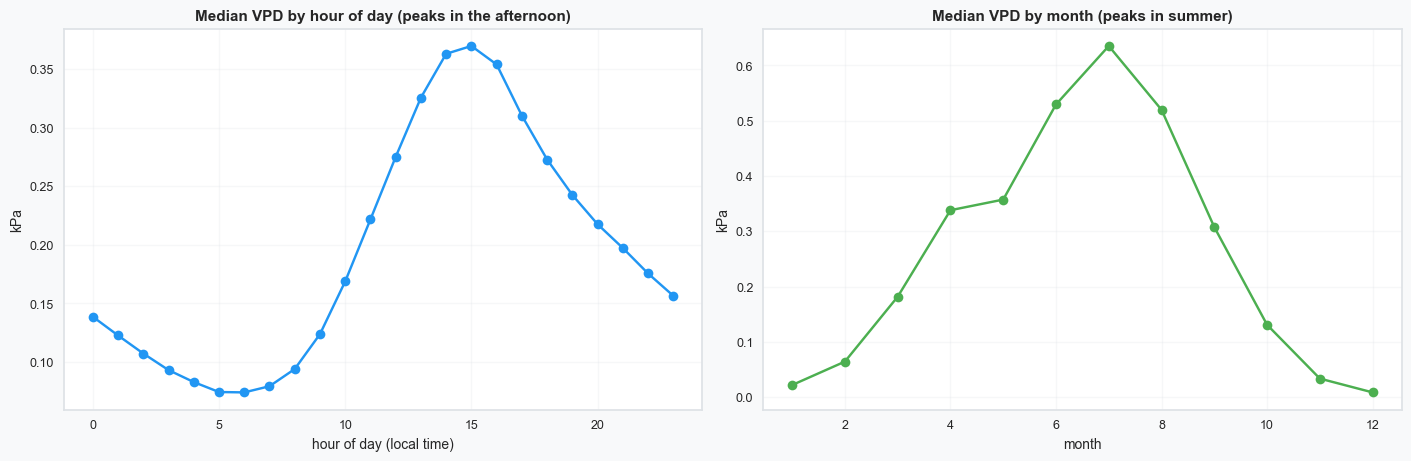

In [12]:
# Diurnal and seasonal behaviour of the computed VPD, as a second check that it is physical.
fig, axs = plt.subplots(ncols=2, figsize=(14, 4.5), dpi=100, layout='constrained')

_by_hour = df[TARGET].groupby(df.index.hour).median()
_by_hour.plot(ax=axs[0], marker='o', color='#2196F3')
axs[0].set_xlabel('hour of day (local time)')
axs[0].set_ylabel('kPa')
axs[0].set_title('Median VPD by hour of day (peaks in the afternoon)', fontsize=11)

_by_month = df[TARGET].groupby(df.index.month).median()
_by_month.plot(ax=axs[1], marker='o', color='#4CAF50')
axs[1].set_xlabel('month')
axs[1].set_ylabel('kPa')
axs[1].set_title('Median VPD by month (peaks in summer)', fontsize=11)

***

# 🟦 Drivers

Three drivers are used for the gap-filling, all of them complete over the whole record so that no
record has to fall back to the weaker timestamp-only model:

- **Gap-filled `TA`** from notebook `32`. `TA` is one of the two variables `VPD` is made of, so it
  is by far the strongest predictor available.
- **Gap-filled `SW_IN`** from notebook `31`. Radiation drives the evaporative demand that `VPD`
  measures, and it is a *measured* signal, which is what separates a real dry afternoon from an
  ordinary one at the same temperature.
- **`SW_IN_POT`**, potential radiation, computed from the site coordinates. It carries **day
  length, season and the day/night distinction** in a single continuous variable and never has
  gaps. `VPD` behaves quite differently by day and by night — daytime values are driven by heating
  and mixing, nighttime values collapse towards zero as the air approaches saturation — so a
  feature that separates the two without depending on any sensor is worth having.

`RH` is deliberately **not** a driver. It is missing at exactly the records that need filling, so
it could contribute nothing there and would only push records to the fallback model.

::: {.callout-note title="What the model is really doing"}
Because `TA` is a driver and `VPD = f(TA, RH)`, the model is effectively predicting the missing
`RH` and pushing it through the formula. That is a fair description of the skill on offer: the
temperature part of `VPD` is known exactly at every gap, and only the humidity part is estimated.
It also means the held-out scores below are better than they would be for a variable whose drivers
are merely correlated with it, and should be read with that in mind.
:::

Notebooks `31`, `32` and `34` have to be run before this one.

In [13]:
# SW_IN_POT from the site coordinates, on the same local-time axis as the data.
swinpot = dv.variables.potrad(
    timestamp_index=df.index,
    lat=SITE_LAT,
    lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
)

drivers = pd.DataFrame(index=df.index)
drivers[TA_COL] = df[TA_COL]
drivers[SWIN_COL] = df[SWIN_COL]
drivers['SW_IN_POT'] = swinpot

# All drivers must be complete, otherwise records fall back to the timestamp-only model.
print(drivers.isnull().sum().rename('missing values'))
assert drivers.notna().all().all(), "a driver has gaps - check notebooks 01 and 02"
drivers.describe()

TA_T1_47_1_gfXG       0
SW_IN_T1_47_1_gfXG    0
SW_IN_POT             0
Name: missing values, dtype: int64


,TA_T1_47_1_gfXG,SW_IN_T1_47_1_gfXG,SW_IN_POT
count,385728.000000,385728.000000,385728.000000
mean,8.950689,145.499029,298.951202
std,8.162505,239.720112,382.633189
min,-17.200001,0.000000,0.000000
25%,2.619000,0.000000,0.000000
50%,8.890000,4.008015,17.494992
75%,15.000000,196.845521,566.632430
max,33.558765,1118.658439,1214.125501


Records with SW_IN_POT == 0 (night): 184,260 (47.8%)
median VPD at night: 0.108 kPa
median VPD by day:   0.258 kPa


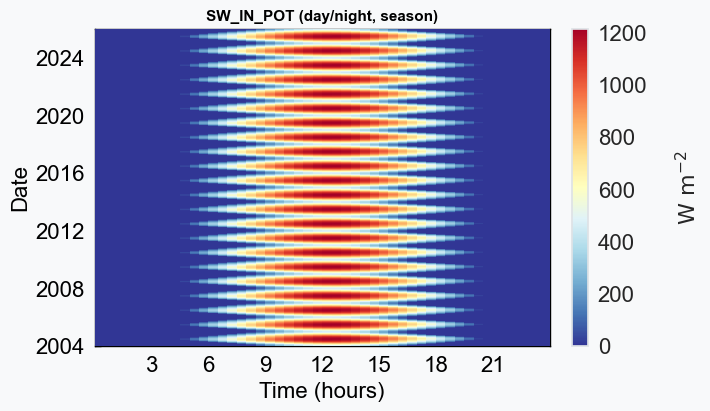

In [14]:
# SW_IN_POT is only useful here if it really separates day from night. Nighttime VPD should sit
# far below daytime VPD; if it does not, the potential radiation is on the wrong time axis.
_night = drivers['SW_IN_POT'] == 0
print(f"Records with SW_IN_POT == 0 (night): {int(_night.sum()):,} "
      f"({100 * _night.mean():.1f}%)")
print(f"median VPD at night: {float(df[TARGET][_night].median()):.3f} kPa")
print(f"median VPD by day:   {float(df[TARGET][~_night].median()):.3f} kPa")
assert float(df[TARGET][_night].median()) < float(df[TARGET][~_night].median()), \
    "nighttime VPD is not lower than daytime VPD - SW_IN_POT is probably misaligned in time"

fig, ax = plt.subplots(figsize=(7, 4), dpi=100, layout='constrained')
dv.plotting.HeatmapDateTime(series=drivers['SW_IN_POT']).plot(
    ax=ax, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
    format_style=dv.plotting.FormatStyle(title='SW_IN_POT (day/night, season)',
                                         title_fontsize=11))

***

# 🟥 Gap-filling

## Method

The same setup as notebook `32`: the general `XGBoostTS` gap-filler with an explicit
`FeatureEngineer`, SHAP-based feature reduction, and short gaps filled by interpolation rather than
by the model. The radiation-specific `SWINGapFillerXGBoost` used in notebook `31` is not applicable
here — it forces nighttime values to zero, and while nighttime `VPD` is *low* it is not zero.

The settings carried over from notebook `32`, and why:

- **`features_lag=[]`.** The model only predicts records where every feature is present. A lag of a
  driver would turn "my neighbour is missing" into "I cannot be filled", pushing records to the
  weaker timestamp-only fallback.
- **`SW_IN_POT` is excluded from the rolling and EMA stages.** It follows from the timestamp alone,
  so smoothed versions of it repeat what its raw value and the timestamp features already say.
- **`shap_max_rows=10_000`.** SHAP importances are the slowest part of a run and are computed four
  times per call. The mean importances settle long before the full record is used, so the rows are
  capped. Predictions and scores are untouched, and the sample stays reproducible through
  `random_state`.
- **Hyperparameters are given explicitly**, since the general `XGBoostTS` ships no tuned defaults.

**Short gaps** (up to 1 h) are filled by linear interpolation afterwards and flagged `4`. The
feature engineer excludes the target from its own features, so a short gap is exactly the case the
model is blind to. `VPD` is continuous across midnight, so the interpolation is not restricted to
single days.

**Training data.** The model trains on every record that has a `VPD`, which includes the `5` and `6`
records — a gap-filled `TA` or a reconstructed `RH` still produces a usable `VPD`, and excluding
them would discard a large share of the pre-2019 record for a modest gain in purity. What it must
not do is *forget* that they are not measurements, which is what the flag is for.

In [15]:
SHAP_MAX_ROWS = 10_000  # rows used for SHAP importances, see the note above


def gapfill_vpd(target: pd.Series,
                drivers: pd.DataFrame,
                interpolate_limit: int = 2,
                reduce_features: bool = True,
                verbose: int = 1):
    """Gap-fill VPD with XGBoost, then interpolate the remaining short gaps.

    Returns (model, gapfilled, flag). `gapfilled` carries the `_gfXG` name; `flag` uses the
    standard gap-filling codes only (0/1/2/4) and is merged with the provenance codes afterwards.
    """
    input_df = pd.concat([target, drivers], axis=1)

    engineer = dv.gapfilling.FeatureEngineer(
        target_col=target.name,
        features_lag=[],  # see the note above
        features_rolling=[4, 8, 24, 48],  # 2h, 4h, 12h, 24h on 30MIN data
        features_rolling_stats=['median'],
        features_rolling_exclude_cols=['SW_IN_POT'],  # deterministic, see the note above
        features_ema=[6, 24],  # 3h, 12h
        features_ema_exclude_cols=['SW_IN_POT'],
        vectorize_timestamps=True,
        add_continuous_record_number=True,
        verbose=0,
    )
    features_df = engineer.fit_transform(input_df)
    print(f"Features: {features_df.shape[1] - 1} over {len(features_df):,} records")

    model = dv.gapfilling.XGBoostTS(
        input_df=features_df,
        target_col=target.name,
        verbose=verbose,
        shap_max_rows=SHAP_MAX_ROWS,
        n_estimators=3000,
        max_depth=6,
        early_stopping_rounds=20,
        random_state=42,
        n_jobs=-1,
    )
    model.trainmodel(showplot_scores=False, showplot_importance=False)
    if reduce_features:
        model.reduce_features()
        model.trainmodel(showplot_scores=False, showplot_importance=False)
    model.fillgaps(showplot_scores=False, showplot_importance=False)

    gapfilled = model.results.gapfilled.copy()
    flag = model.results.flag.copy()

    if interpolate_limit:
        short = short_gap_mask(target, interpolate_limit)
        interp = target.interpolate(method='time', limit_area='inside')
        fill_locs = short & interp.notna()
        gapfilled[fill_locs] = interp[fill_locs]
        flag[fill_locs] = 4
        print(f"Short-gap interpolation: {int(fill_locs.sum())} records")

    gapfilled = gapfilled.rename(f"{target.name}_gfXG")
    flag = flag.rename(f"FLAG_{target.name}_ISFILLED")
    return model, gapfilled, flag

In [16]:
%%time

gf_vpd, gapfilled_vpd, model_flag = gapfill_vpd(
    target=df[TARGET],
    drivers=drivers,
)

Features: 46 over 385,728 records
Short-gap interpolation: 10 records
CPU times: total: 1h 17min 24s
Wall time: 5min 43s


## Results: scores and feature importances

In [17]:
print("Held-out (train/test) scores:")
display(pd.Series(gf_vpd.results.scores_traintest))
print("Gap-filling flag counts (before the provenance codes are merged in):")
display(model_flag.value_counts().sort_index().rename(index=FLAG_LEGEND))

Held-out (train/test) scores:


mae      3.457673e-02
medae    2.233736e-02
mse      2.624251e-03
rmse     5.122745e-02
mape     4.300149e+11
maxe     5.241539e-01
r2       9.874594e-01
dtype: float64

Gap-filling flag counts (before the provenance codes are merged in):


FLAG_VPD_T1_47_1_ISFILLED
0 = computed from measured TA and measured RH         384808
1 = gap-filled by the XGBoost model                      910
4 = gap-filled by linear interpolation (short gap)        10
Name: count, dtype: int64

In [18]:
gf_vpd.results.feature_importances

,SHAP_IMPORTANCE,SHAP_SD
TA_T1_47_1_gfXG,0.342018,0.305669
.SW_IN_T1_47_1_gfXG_MEAN48,0.064502,0.041454
.SW_IN_T1_47_1_gfXG_EMA24,0.054561,0.048626
.DOY_COS,0.051143,0.040726
.TA_T1_47_1_gfXG_MEAN48,0.039317,0.031877
...,...,...
.TA_T1_47_1_gfXG_SD8,0.005320,0.005609
.SW_IN_T1_47_1_gfXG_ROLLMEDIAN8,0.005029,0.007137
.SEASON_COS,0.004553,0.003178
.MONTH_COS,0.004527,0.004875


## Clip the predictions at zero

`VPD` cannot be negative, but nothing in the model knows that: XGBoost extrapolates and can return
a small negative value where the true value is near saturation. Those are clipped to `0`.

The clip is applied **only to modelled records**. A computed record that came out negative would be
a real problem — it would mean an `RH` above 100% survived notebook `34` — and must raise rather
than be quietly flattened, so it is checked separately.

In [19]:
_modelled = model_flag.isin(MODELLED_FLAGS)

_negative_computed = (df[TARGET] < 0).sum()
assert _negative_computed == 0, \
    f"{_negative_computed} computed VPD values are negative - check RH in notebook 04"

_negative_modelled = gapfilled_vpd[_modelled] < 0
print(f"Modelled records:              {int(_modelled.sum()):,}")
print(f"Negative modelled predictions: {int(_negative_modelled.sum()):,}")
if _negative_modelled.any():
    print(f"  most negative: {float(gapfilled_vpd[_modelled].min()):.4f} kPa")

gapfilled_vpd[_modelled & (gapfilled_vpd < 0)] = 0.0
print(f"\nAfter clipping: min {float(gapfilled_vpd.min()):.4f} kPa")
check_vpd_range(gapfilled_vpd, gapfilled_vpd.name)

Modelled records:              920
Negative modelled predictions: 101
  most negative: -0.3364 kPa

After clipping: min 0.0000 kPa
  VPD_T1_47_1_gfXG                   n=385,728  median 0.170  range 0.000..4.036 kPa


## Merge the model flag with the provenance codes

The model's flag says `0` for every record it did not have to fill, which for a derived variable is
not the whole story. The provenance codes built before the fill are written back over those `0`s,
so the final flag says both *whether* a record was modelled and, if it was not, *what it was
computed from*.

In [20]:
flag = model_flag.copy()

# Where the model filled a gap, keep its code. Everywhere else, use the provenance code.
_filled = flag.isin(MODELLED_FLAGS)
flag[~_filled] = provenance[~_filled]
flag = flag.astype(int).rename(f"FLAG_{TARGET}_ISFILLED")

# Consistency: the two classifications must partition the record exactly.
assert flag.notna().all(), "a record has no flag"
assert set(flag.unique()).issubset(set(FLAG_LEGEND)), \
    f"unknown flag code(s): {sorted(set(flag.unique()) - set(FLAG_LEGEND))}"
assert flag.isin(MODELLED_FLAGS).equals(_filled), "modelled records changed during the merge"
assert flag.isin(COMPUTED_FLAGS).equals(computed), \
    "a computed record is no longer flagged as computed"

_counts = flag.value_counts().sort_index()
display(pd.DataFrame({'count': _counts, '%': (100 * _counts / len(flag)).round(2)})
        .rename(index=FLAG_LEGEND))
print(f"Purely measured (flag 0): {100 * (flag == 0).mean():.2f}%  |  "
      f"Computed, not purely measured (5, 6): {100 * flag.isin((5, 6)).mean():.2f}%  |  "
      f"Modelled (1, 2, 4): {100 * flag.isin(MODELLED_FLAGS).mean():.2f}%")

,count,%
FLAG_VPD_T1_47_1_ISFILLED,,
0 = computed from measured TA and measured RH,369056,95.68
1 = gap-filled by the XGBoost model,910,0.24
4 = gap-filled by linear interpolation (short gap),10,0.00
5 = computed from measured RH and gap-filled TA,23,0.01
6 = computed from RH reconstructed from NABEL (TA measured or gap-filled),15729,4.08


Purely measured (flag 0): 95.68%  |  Computed, not purely measured (5, 6): 4.08%  |  Modelled (1, 2, 4): 0.24%


***

# ➡️ Prepare dataframe for export

In [21]:
VALCOL = f"{TARGET}_gfXG"
FLAGCOL = f"FLAG_{TARGET}_ISFILLED"

export_df = pd.concat([gapfilled_vpd.rename(VALCOL), flag.rename(FLAGCOL)], axis=1)
export_df

,VPD_T1_47_1_gfXG,FLAG_VPD_T1_47_1_ISFILLED
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,0.010904,6
2004-01-01 00:45:00,0.014704,6
2004-01-01 01:15:00,0.031038,6
2004-01-01 01:45:00,0.035081,6
2004-01-01 02:15:00,0.028744,6
...,...,...
2025-12-31 21:45:00,0.280473,0
2025-12-31 22:15:00,0.295503,0
2025-12-31 22:45:00,0.209658,0


Sanity check: the exported series must be complete (no gaps), non-negative, physically plausible in
kPa, and the index must be continuous 30MIN with no duplicates. Every record must carry a flag.

`FLAG_VPD_T1_47_1_ISFILLED` travels with the product so downstream users can tell the three classes
apart. Flag `0` is computed from two measurements; `5` and `6` are computed but rest on a filled or
reconstructed input; `1`, `2` and `4` were produced by the gap-filling here.

In [22]:
print(f"Records:         {len(export_df):,}")
print(f"Missing values:  {export_df[VALCOL].isnull().sum()}")
print(f"Missing flags:   {export_df[FLAGCOL].isnull().sum()}")
print(f"Negative values: {(export_df[VALCOL] < 0).sum()}")
print(f"Duplicate index: {export_df.index.duplicated().sum()}")
print(f"Index gaps:      "
      f"{(export_df.index.to_series().diff().dropna() != pd.Timedelta('30min')).sum()}")
print(f"Index:           {export_df.index[0]} -> {export_df.index[-1]}")
print(f"Min / max:       {export_df[VALCOL].min():.3f} / {export_df[VALCOL].max():.3f} kPa")

assert export_df[VALCOL].notna().all(), "the exported series is not complete"
assert export_df[FLAGCOL].notna().all(), "a record has no flag"
assert export_df.index.duplicated().sum() == 0, "duplicate timestamps"
assert (export_df.index.to_series().diff().dropna() == pd.Timedelta('30min')).all(), \
    "index not continuous 30MIN"
check_vpd_range(export_df[VALCOL], VALCOL)

print("\nFill provenance:")
_counts = export_df[FLAGCOL].value_counts().sort_index()
display(pd.DataFrame({'count': _counts, '%': (100 * _counts / len(export_df)).round(2)})
        .rename(index=FLAG_LEGEND))

export_df.describe()

Records:         385,728
Missing values:  0
Missing flags:   0
Negative values: 0
Duplicate index: 0
Index gaps:      0
Index:           2004-01-01 00:15:00 -> 2025-12-31 23:45:00
Min / max:       0.000 / 4.036 kPa
  VPD_T1_47_1_gfXG                   n=385,728  median 0.170  range 0.000..4.036 kPa

Fill provenance:


,count,%
FLAG_VPD_T1_47_1_ISFILLED,,
0 = computed from measured TA and measured RH,369056,95.68
1 = gap-filled by the XGBoost model,910,0.24
4 = gap-filled by linear interpolation (short gap),10,0.00
5 = computed from measured RH and gap-filled TA,23,0.01
6 = computed from RH reconstructed from NABEL (TA measured or gap-filled),15729,4.08


,VPD_T1_47_1_gfXG,FLAG_VPD_T1_47_1_ISFILLED
count,385728.000000,385728.000000
mean,0.351893,0.247426
std,0.457291,1.187871
min,0.000000,0.000000
25%,0.014521,0.000000
50%,0.170427,0.000000
75%,0.518289,0.000000
max,4.035805,6.000000


## Per-year statistics

The per-year median is the check that nothing stepped: `VPD` is weather, so the interannual spread
should be small and there should be no jump at 2018/2019, where the NABEL sensor behind the `RH`
reconstruction ends and the fill switches from `6` to `1`.

`measured_%` shows how much of each year rests on two genuine measurements. It is lowest where
notebook `34` had to reconstruct `RH` and where notebook `32` had to fill `TA`.

In [23]:
_yr = export_df[VALCOL].groupby(export_df.index.year).agg(['count', 'median', 'min', 'max', 'std'])
_yr['measured_%'] = (100 * (export_df[FLAGCOL] == 0)
                     .groupby(export_df.index.year).mean()).round(2)
_yr['computed_%'] = (100 * export_df[FLAGCOL].isin(COMPUTED_FLAGS)
                     .groupby(export_df.index.year).mean()).round(2)
_yr['modelled_%'] = (100 * export_df[FLAGCOL].isin(MODELLED_FLAGS)
                     .groupby(export_df.index.year).mean()).round(2)
display(_yr.round(3))

_med = _yr['median']
print(f"Yearly medians between {_med.min():.3f} and {_med.max():.3f} kPa "
      f"(spread {_med.max() - _med.min():.3f} kPa)")

,count,median,min,max,std,measured_%,computed_%,modelled_%
TIMESTAMP_MIDDLE,,,,,,,,
2004,17568,0.169,0.000,2.802,0.407,28.02,99.97,0.03
2005,17520,0.168,0.003,2.939,0.431,99.81,99.86,0.14
2006,17520,0.179,0.000,3.309,0.453,99.85,100.00,0.00
2007,17520,0.180,0.000,3.143,0.404,99.93,100.00,0.00
2008,17568,0.181,0.002,2.351,0.361,99.89,100.00,0.00
2009,17520,0.191,0.000,2.766,0.403,97.23,100.00,0.00
2010,17520,0.139,0.000,2.857,0.414,99.04,100.00,0.00
2011,17520,0.226,0.000,3.002,0.443,99.88,99.94,0.06
2012,17568,0.173,0.000,3.075,0.411,92.81,100.00,0.00


Yearly medians between 0.100 and 0.234 kPa (spread 0.135 kPa)


,0 = computed from measured TA and measured RH,1 = gap-filled by the XGBoost model,4 = gap-filled by linear interpolation (short gap),5 = computed from measured RH and gap-filled TA,6 = computed from RH reconstructed from NABEL (TA measured or gap-filled)
year,,,,,
2004,4922,6,0,0,12640
2005,17486,24,0,0,10
2006,17493,0,0,0,27
2007,17507,0,0,0,13
2008,17548,0,0,0,20
2009,17034,0,0,0,486
2010,17351,0,0,0,169
2011,17499,9,1,0,11
2012,16305,0,0,3,1260


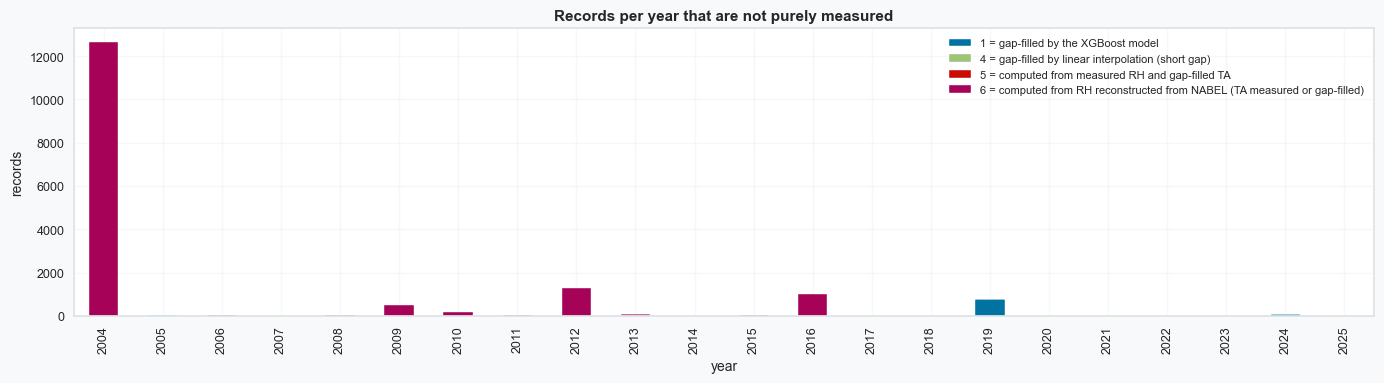

In [24]:
# Records per year and flag, plus the filled ones as a stacked bar chart.
_tab = (pd.crosstab(export_df.index.year, export_df[FLAGCOL])
        .rename(columns=lambda f: FLAG_LEGEND.get(f, f))
        .rename_axis(index='year', columns=None))
_not_measured = _tab.drop(columns=[c for c in _tab.columns if str(c).startswith('0 =')],
                          errors='ignore')
if not _not_measured.empty and _not_measured.to_numpy().sum() > 0:
    ax = _not_measured.plot(kind='bar', stacked=True, figsize=(14, 4),
                            title='Records per year that are not purely measured')
    ax.set_ylabel('records')
    ax.legend(fontsize=8)
    plt.tight_layout()
display(_tab)

## Where the modelled records sit

The flag counts above say *how many* records were modelled. They do not say whether those records
are scattered half-hours or one long outage, and the difference matters more than the count does.

The held-out scores reported by the gap-filling are computed on records drawn from the whole
series, so almost every test record still has measured neighbours a few hours away. A block
spanning weeks has none, and the scores say very little about it. So the modelled records are
grouped into contiguous blocks here, and any block longer than a week is named rather than left to
be discovered from the flag column.

In [ ]:
LONG_BLOCK_DAYS = 7  # a block longer than this is called out below rather than just counted

_mod = export_df[FLAGCOL].isin(MODELLED_FLAGS)
_runs = (_mod != _mod.shift()).cumsum()[_mod]
_blocks = pd.DataFrame(
    [(v.index[0], v.index[-1], len(v), len(v) / 48)
     for _, v in _mod[_mod].groupby(_runs)],
    columns=['start', 'end', 'records', 'days'])

if _blocks.empty:
    print("No modelled records at all.")
else:
    _blocks = _blocks.sort_values('records', ascending=False).reset_index(drop=True)
    print(f"Modelled records: {int(_mod.sum()):,} in {len(_blocks):,} contiguous block(s)")
    print(f"Longest block:    {_blocks['days'].iloc[0]:.1f} days "
          f"({int(_blocks['records'].iloc[0]):,} records, "
          f"{_blocks['start'].iloc[0]} -> {_blocks['end'].iloc[0]})")
    print(f"Median block:     {_blocks['records'].median():.0f} record(s)")
    display(_blocks.head(10).round({'days': 2}))

    _long = _blocks[_blocks['days'] > LONG_BLOCK_DAYS]
    if len(_long):
        print(f"\n{len(_long)} block(s) longer than {LONG_BLOCK_DAYS} days, covering "
              f"{int(_long['records'].sum()):,} records "
              f"({100 * _long['records'].sum() / len(export_df):.2f}% of the whole product). "
              f"See the downstream note at the end of this notebook.")
    else:
        print(f"\nNo block longer than {LONG_BLOCK_DAYS} days.")

Text(0, 0.5, '%')

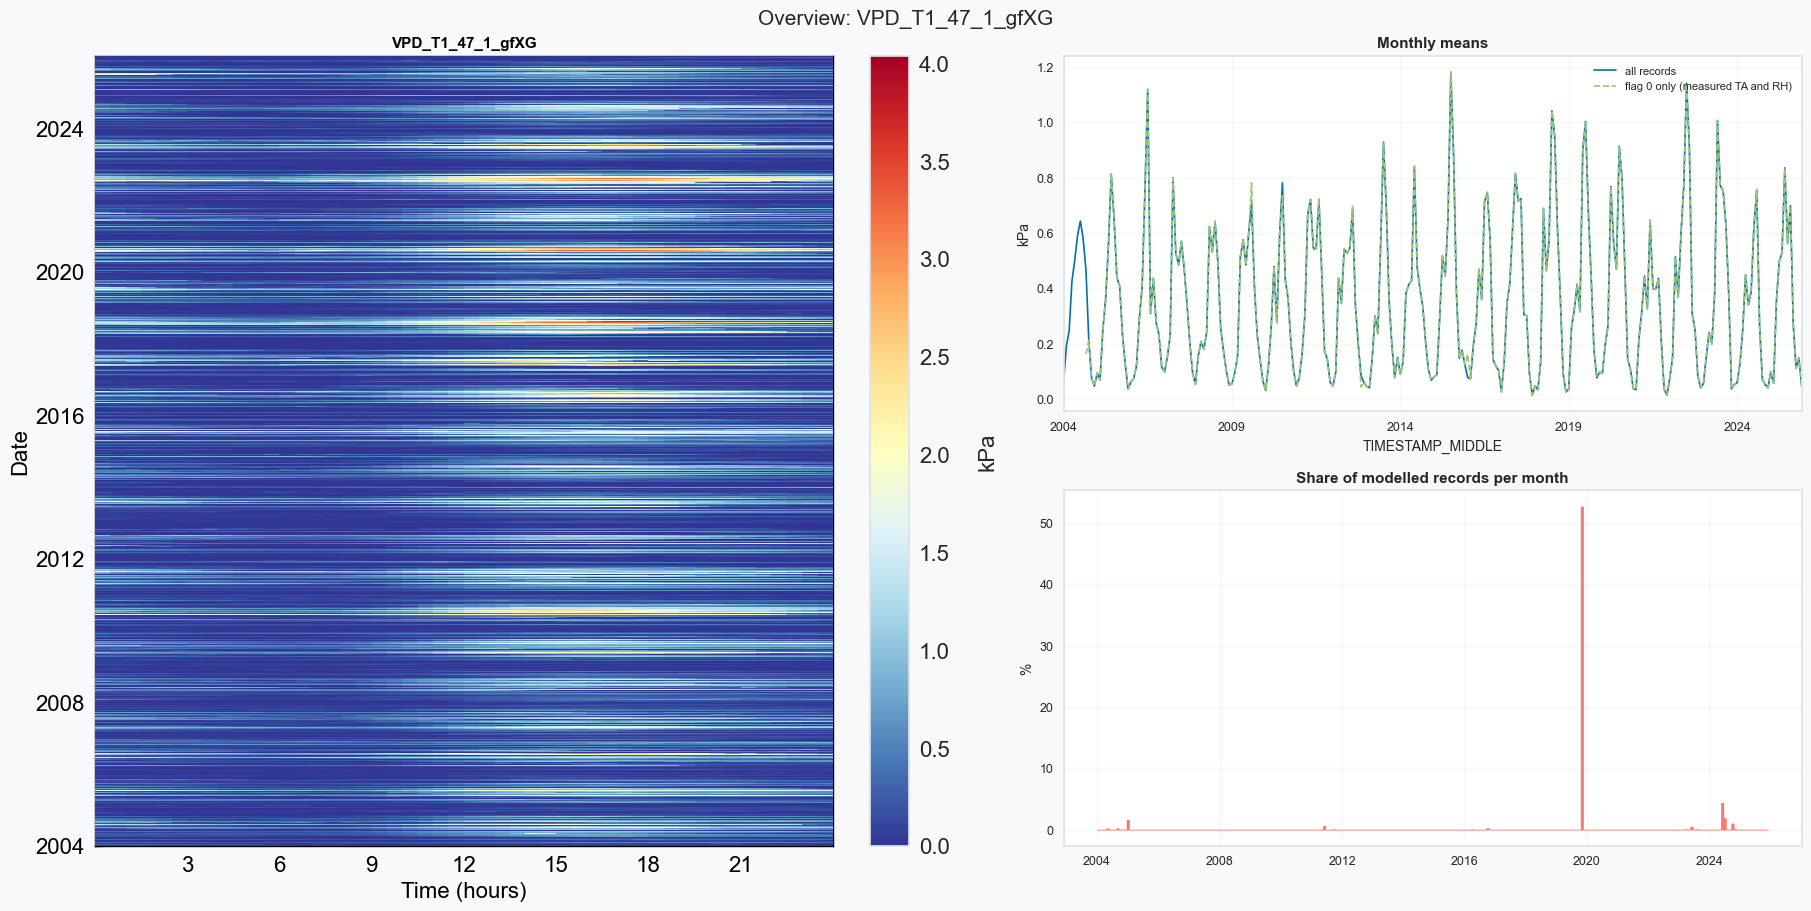

In [25]:
fig = plt.figure(figsize=(18, 9), dpi=100, layout='constrained')
gs = gridspec.GridSpec(2, 2, figure=fig)
fig.suptitle(f'Overview: {VALCOL}', fontsize=15)

ax = fig.add_subplot(gs[:, 0])
dv.plotting.HeatmapDateTime(series=export_df[VALCOL]).plot(
    ax=ax, cb_digits_after_comma=1, zlabel='kPa',
    format_style=dv.plotting.FormatStyle(title=VALCOL, title_fontsize=11))

# Monthly means of everything against the purely measured records only. A gap between the two
# lines means the non-measured records are biased.
ax = fig.add_subplot(gs[0, 1])
export_df[VALCOL].resample('MS').mean().plot(ax=ax, label='all records', lw=1.2)
export_df[VALCOL].where(export_df[FLAGCOL] == 0).resample('MS').mean().plot(
    ax=ax, label='flag 0 only (measured TA and RH)', lw=1.2, ls='--')
ax.set_title('Monthly means', fontsize=11)
ax.set_ylabel('kPa')
ax.legend(fontsize=8)

ax = fig.add_subplot(gs[1, 1])
_share = export_df[FLAGCOL].isin(MODELLED_FLAGS).resample('MS').mean() * 100
ax.fill_between(_share.index, _share.values, step='mid', alpha=.7, color='#F44336')
ax.set_title('Share of modelled records per month', fontsize=11)
ax.set_ylabel('%')

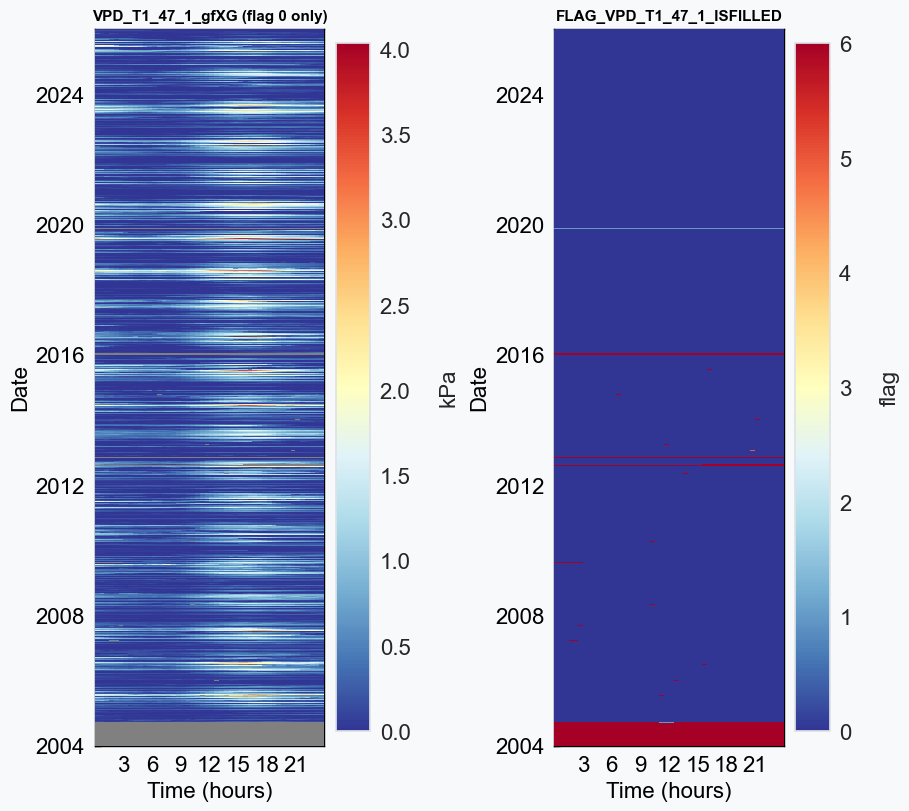

In [26]:
fig, axs = plt.subplots(ncols=2, figsize=(9, 8), dpi=100, layout='constrained')
dv.plotting.HeatmapDateTime(series=export_df[VALCOL].where(export_df[FLAGCOL] == 0)).plot(
    ax=axs[0], cb_digits_after_comma=1, zlabel='kPa',
    format_style=dv.plotting.FormatStyle(title=f'{VALCOL} (flag 0 only)', title_fontsize=11))
dv.plotting.HeatmapDateTime(series=export_df[FLAGCOL].astype(float)).plot(
    ax=axs[1], cb_digits_after_comma=0, zlabel='flag',
    format_style=dv.plotting.FormatStyle(title=FLAGCOL, title_fontsize=11))

***

# 💾 Save to file

In [27]:
filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")
print(f"Saved to: {filepath}")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\07_METEO
_VPD_GAPFILLED_2004-2025.parquet (0.403 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\07_METEO_VPD_GAPFILLED_2004-2025.parquet


## Verify the written file

Reading the parquet back and checking it directly, rather than trusting the in-memory frame.

In [28]:
_written = dv.load_parquet(filepath=str(Path(OUTPATH) / f"{OUTNAME}.parquet"))

print(f"columns:   {list(_written.columns)}")
print(f"index:     {_written.index[0]} -> {_written.index[-1]}  ({len(_written):,} records)")
print(f"missing:   {int(_written[VALCOL].isna().sum())}")
print(f"median:    {float(_written[VALCOL].median()):.3f} kPa")
print(f"min / max: {float(_written[VALCOL].min()):.3f} / {float(_written[VALCOL].max()):.3f} kPa")

assert list(_written.columns) == [VALCOL, FLAGCOL], "unexpected columns in the written file"
assert len(_written) == len(export_df), "record count changed on write"
assert _written[VALCOL].equals(export_df[VALCOL]), "values differ from what was written"
assert _written[FLAGCOL].equals(export_df[FLAGCOL]), "flags differ from what was written"
check_vpd_range(_written[VALCOL], f"{VALCOL} (read back)")
print("\nWritten file verified.")

display(_written[VALCOL].groupby(_written.index.year).median().round(3)
        .rename('yearly median (kPa)'))

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\07_METEO
_VPD_GAPFILLED_2004-2025.parquet (0.023 seconds).

columns:   ['VPD_T1_47_1_gfXG', 'FLAG_VPD_T1_47_1_ISFILLED']
index:     2004-01-01 00:15:00 -> 2025-12-31 23:45:00  (385,728 records)
missing:   0
median:    0.170 kPa
min / max: 0.000 / 4.036 kPa
  VPD_T1_47_1_gfXG (read back)       n=385,728  median 0.170  range 0.000..4.036 kPa

Written file verified.


TIMESTAMP_MIDDLE
2004    0.169
2005    0.168
2006    0.179
2007    0.180
2008    0.181
2009    0.191
2010    0.139
2011    0.226
2012    0.173
2013    0.121
2014    0.186
2015    0.234
2016    0.127
2017    0.187
2018    0.179
2019    0.173
2020    0.202
2021    0.132
2022    0.219
2023    0.175
2024    0.100
2025    0.153
Name: yearly median (kPa), dtype: float64

***

# ⚠️ Note for downstream notebooks

`VPD_T1_47_1_gfXG` is **complete**: there are no `NaN` in it, unlike the `RH` it is built from.
Whatever reads this file does not have to cope with gaps, but it does have to decide how much of
the series it is willing to treat as observation.

`FLAG_VPD_T1_47_1_ISFILLED` tells a consumer what it is looking at:

- `0` — computed from a measured `TA` and a measured `RH` at 47 m. The only records where nothing
  upstream was modelled or transferred.
- `5` — computed from a measured `RH` and a `TA` that notebook `32` gap-filled. `TA` fills are
  skilful, so these are good values, but they are not two measurements.
- `6` — computed from an `RH` reconstructed from the NABEL sensor at 49 m by notebook `34`, which
  carries about **3 % RH** of uncertainty. Anything estimating measurement uncertainty, or fitting
  a relationship where humidity is the independent variable, should consider excluding these.
- `1` / `2` / `4` — produced by the gap-filling here: `1` by the XGBoost model, `2` by the
  timestamp-only fallback, `4` by interpolation across a gap of at most one hour.

Two filters cover most uses: `flag == 0` for genuine measurements only, `flag in (0, 5, 6)` for
every value that follows from `TA` and `RH` rather than from a `VPD` model.

## The November 2019 outage

One block deserves naming, because it is unlike every other modelled record in this product.

The 47 m humidity sensor was down from **4 November 2019 04:45 to 19 November 2019 23:45** —
**759 consecutive records, 15.8 days**, and **52.7 % of that month**. Notebook `34` carries them as
flag `1`, never measured. They are 82.5 % of every remaining gap in the `RH` product (759 of 920),
which is why they dominate the modelled share and why every other month in the overview plot looks
flat by comparison.

Nothing could be reconstructed from NABEL, because NABEL ends in 2018. An outage of this length
before 2019 would have come through as flag `6`; after 2018 there is no second humidity sensor,
so it had to be modelled. This is exactly the consequence notebook `34`'s closing note anticipates.

The fill is plausible. It sits between the measured Novembers of the record and the measured part
of its own month, it stays far below the November maximum, and it keeps a diurnal cycle peaking in
the early afternoon, which is `SW_IN_POT` and the gap-filled `TA` doing their work:

| | median | mean | max |
|---|---|---|---|
| the filled block | 0.044 | 0.071 | 0.509 |
| measured part of Nov 2019 | 0.014 | 0.082 | — |
| all measured Novembers, 2004-2025 | 0.032 | 0.105 | 1.212 |

(kPa.)

**But plausible is not measured, and the held-out scores above do not cover this case.** They are
computed on records scattered through the series, nearly all of which have measured neighbours
within hours. A 15.8-day block has none. What keeps it defensible is that `TA` is known exactly
across the whole gap, so only the humidity half of `VPD` is estimated — but a fortnight of
estimated humidity is still a fortnight of estimated humidity.

Treat November 2019 as modelled, not observed. `flag == 0` excludes it, and so does any filter
built on the block table printed above.

Because `VPD` inherits from two products, its provenance is **not** the same as either of theirs.
A record can be `0` in notebook `34`'s `RH` flag and still not be `0` here, because the `TA` behind
it was filled. Anything combining these products should use each one's own flag rather than
assuming they agree.

# End of notebook.

In [29]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")

Started:  2026-07-20 14:52:05
Finished: 2026-07-20 14:58:08
Runtime:  00:06:02 (hh:mm:ss)
